In [ ]:
'''





See in context of entire data analytics Pipeline, there are couple of imp packages which will help u alot :

Pandas 




'''

## 1.. How to read data from sqlite3 !

In [ ]:
### lets import all the necessary packages !

In [2]:
### import necessary packages 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

In [ ]:
'''

Coming to Source of data , 
we have entire data in this sqlite database that we have actually taken from Kaggle !

Now u may ask : What is Database ?


What is a database ?

A database is like a digital notebook where data is stored in an organized way, 
so we can save, search, and update information easily..

    a) Relational Dbs
    b) Non relational Dbs 
    

    
Relational Dbs
    Here data is stored in the form of tables (rows , cols) , thats why they are known as Table centric dbs..
    There are lot of SQL dbs in market likeMYSQL , PostGreSQL , SQLite , Microsoft SQL Server
    & u can actually use query langauge "SQL" to fetch data from all these SQL dbs!



Non relational Dbs 
    data is stored in the form of documents,  ie key-value pair ! , thats why they are document-centric dbs..
    There are lot of NoSQL dbs in market like : MongoDB , Cassandra , Redis !

    MongoDB Query Language (MQL)
    CQL (Cassandra Query Language)


'''

In [ ]:
'''

See In order to extract data from SQLite db , u have to follow 2 steps:

1 ) Establish connection to SQLite db
2 ) Then u have to find table name  , bcz inside table , we have all the data in the forms of rows , cols
    Then Using "SQL query" , u can extract data from table..



'''

In [3]:
import sqlite3 ## import sqlite3 package to interact with our sqlite database !

In [ ]:
'''

Make sure u have used raw string before file path so that Python is able to understand your file path efficiently !

'''

In [4]:
# very first u have to create a SQL connection to our SQLite database !

con = sqlite3.connect(r"R:\All_Datasets\2.. Zomato\Datasets/zomato_rawdata.sqlite")

In [ ]:
## Once your connection to database is ready , then u have to find table name & then extract data from table !

In [5]:
## Print all tables present in THAT database

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", con)
tables


,name
0,Users


In [6]:
## Now u have table name , so lets extract data from table 

df = pd.read_sql_query("SELECT * FROM Users" , con)

In [ ]:
'''

SELECT = Extract / pick data

🔹 * (star symbol)  = 👉 Means : extract all the columns & all the rows from Users table !


'''

In [173]:
df.head(2)

,index,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari


In [7]:
df.shape

(51717, 18)

In [9]:
df.columns

Index(['index', 'url', 'address', 'name', 'online_order', 'book_table', 'rate',
       'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [ ]:
'''

So we have collected data 

Now, the moment you collect data, one thing is always true 👉
the data is raw, uncleaned, and messy..





And that’s completely normal — real-world data is never perfect..

Thats why u have clean this data so that u can make insights by Performing Spatial & GIS Analysis !



'''

## 2.. Doing data cleaning ? 


In [ ]:
'''

Hi there , in the last session , we have shed light on Data Collection !


[Show life cycle image]
Moment you collect data, one thing is always true 👉
the data is raw, uncleaned, and messy.
That’s why before doing anything else…
we first need to clean the data.


Alright, before we start data cleaning…
👉 Pause the video for a moment and think:

What kind of cleaning do we actually need in real-world data?
And why is it important?



Now let’s understand
[show img ]
    

U may have duplicate rows in your data & u have to fix it !
You may have to deal with missing rows !
You may have to deal with ir-relevant entries : like u have rating as 4.2/5  , but it must be 4.2


So u can think of adoing all these data cleaning on top of data !




'''

In [ ]:
## lets check whether we have dupliacte rows or not !

In [ ]:
df.duplicated() 

In [9]:
df.duplicated().sum() ## 0 duplicated entries

0

In [10]:
df.head(2)

,index,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari


In [ ]:
## lets find total missing values in data !

In [ ]:
df.isnull()

In [12]:
df.isnull().sum()

index                              0
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [11]:
df.isnull().sum()/len(df)*100

index                           0.000000
url                             0.000000
address                         0.000000
name                            0.000000
online_order                    0.000000
book_table                      0.000000
rate                           15.033741
votes                           0.000000
phone                           2.335789
location                        0.040606
rest_type                       0.438927
dish_liked                     54.291626
cuisines                        0.087012
approx_cost(for two people)     0.669026
reviews_list                    0.000000
menu_item                       0.000000
listed_in(type)                 0.000000
listed_in(city)                 0.000000
dtype: float64

In [ ]:
'''
     -->> As we notice around 50 % of data will be lost if we delete the nan values in dish_liked column , 
         we will losse 50% of data , so lets keep that column for now..
        
     -->> let's check for rate column as it contains 15% of its points as null value which 
         is one of the most important feature.. 
         
'''

In [12]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', None, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

    ->> This none represents missing values in rate col !
    
    -->> 1... we found this column has 'NEW' ,"-" values which should replaced by zero or np.nan 
            after having conversation with my business team ( Domain Expertise)..

    -->> 2...there are values as '3.8/5' instead of 3.8 , ie we have to fix this .. 

#### so lets replace 'NEW' & '-' with np.nan or with "missing value" ,so that we can fill later it with some value..

In [13]:
df['rate'] = df['rate'].replace({'NEW','-'}, np.nan)

In [14]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', nan, '2.9/5', '3.5/5', None, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [ ]:
## now u will see u do not have rating as "NEW"  , "-"

####  we need rating as 4.1 not as '4.1/5' , ie we need to fix it ..

In [15]:
"4.1/5".split('/')[0]

'4.1'

In [16]:
type("4.1/5".split('/')[0])

str

In [17]:
float("4.1/5".split('/')[0])

4.1

In [ ]:
'''

Now we have to applt this whole idea on top of every row of "rate" col !

'''

In [18]:
df['rate'] = df['rate'].apply(lambda x : float(x.split('/')[0]) if type(x)==str else x)

In [19]:
df['rate']

0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51712    3.6
51713    NaN
51714    NaN
51715    4.3
51716    3.4
Name: rate, Length: 51717, dtype: float64

In [20]:
df["rate"].isnull().sum()

10052

In [ ]:
'''

These are the totla misssing values in "rate" col which u can handle later as per the challenges !


'''

In [ ]:
### now lets find missing values of location feature in order to come up with interesting results..

In [21]:
df["location"].isnull().sum()

21

In [22]:
### As we have few missing values in location feature , then we can drop that..

df.dropna(subset = ['location'] , inplace = True)

In [ ]:
'''

Now in the next ssion , [show image]
we will deep dive into : how to extract lat & lon which will help us to perform all the GIS Based or spatial analysis in near future




will see u there , ba bie & gOd bless you !



'''

# 3.. Extract latitudes & longitudes from data 



In [ ]:
'''

Hi there , in the last session , we have shed light on Data pre-processing  !
where we have make our data ready for performing Spatial Analysis !


Now, to perform GIS or spatial analysis
[show plots]

👉 You always need two important things : Latitude and Longitude
And that’s exactly what we are going to focus on in this session!

In simple terms 👉 : All we need are values like this: : [show image ]

'''

In [ ]:
## Now u may ask : What lat & lon are !
## so lets understand : 

In [ ]:
'''

Show img : 


    See Every place on Earth can be located using a unique pair of numbers called coordinates (Lat , Lon) :
    These coordinates are useful for maps, GPS, navigation and to perform Geographical analysis..
    
    
    Before understanding what latitude & Longitude are , we need to know two important imaginary reference lines on Earth:
    Equator & prime meridian 
         Equator → A horizontal line around the middle of the Earth
         Prime Meridian → A vertical line running from the North Pole to the South Pole through Greenwich, England
                          
        
        
    📏 How the Globe Is Divided

        The globe is divided into 2 degrees of measurement :
        360° around the Earth (east ↔ west) → These are Longitude measurements
        180° from top to bottom (north ↕ south) → These are Latitude measurements

 
    
        🧭 What is Longitude ?

            These vertical lines lines that run from the North Pole to the South Pole are called Longitude lines..
            They tell us : how far a place is east or west of the Prime Meridian..
            
        
        
        🌎 What is Latitude?

            These horizontal lines that run around the Earth from east to west are called Latitude lines.
            They measure how far a place is north or south of the Equator.
            


'''

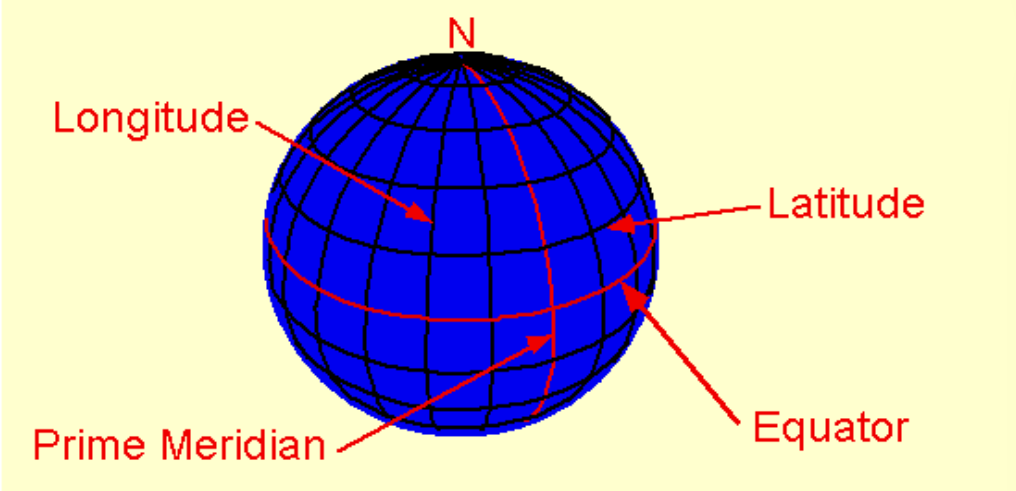

In [23]:
df.shape

(51696, 18)

In [ ]:
'''

Coming to dataset , 

Since your dataset has ~50K rows, the best spatial-analysis approach is NOT to geocode every restaurant location !
That would be slow and unnecessary..

So a Experienced data analyst would geocode only unique locations because many restaurants share the same locality..
& this will be more effective approach !



'''

In [24]:
data = df.copy() ## creating copy of "data" into "df" ,so that whatever manipulations we will do , we will do on top of df

In [ ]:
data["location"]

In [ ]:
### Lets make every place more readible like :   


so that u will get more more accurate geographical co-ordinates..


In [25]:
data['location'] = data['location'].str.strip() + ' , Bangalore , Karnataka , India'

## strip() will remove all the leading and trailing spaces..
## then lets concatenate -----

In [26]:
data['location']

0             Banashankari , Bangalore , Karnataka , India
1             Banashankari , Bangalore , Karnataka , India
2             Banashankari , Bangalore , Karnataka , India
3             Banashankari , Bangalore , Karnataka , India
4             Basavanagudi , Bangalore , Karnataka , India
                               ...                        
51712           Whitefield , Bangalore , Karnataka , India
51713           Whitefield , Bangalore , Karnataka , India
51714           Whitefield , Bangalore , Karnataka , India
51715    ITPL Main Road, Whitefield , Bangalore , Karna...
51716    ITPL Main Road, Whitefield , Bangalore , Karna...
Name: location, Length: 51696, dtype: object

In [ ]:
'''

[show img]
Now at the end , we want uniuq locations of bengaluru city so that we can extract llat & lon 


'''

In [27]:
rest_loc = pd.DataFrame() ## creating dataframe of all the unique locations of Bengalore

In [28]:
rest_loc['Name'] = data['location'].unique()
rest_loc

,Name
0,"Banashankari , Bangalore , Karnataka , India"
1,"Basavanagudi , Bangalore , Karnataka , India"
2,"Mysore Road , Bangalore , Karnataka , India"
3,"Jayanagar , Bangalore , Karnataka , India"
4,"Kumaraswamy Layout , Bangalore , Karnataka , I..."
...,...
88,"West Bangalore , Bangalore , Karnataka , India"
89,"Magadi Road , Bangalore , Karnataka , India"
90,"Yelahanka , Bangalore , Karnataka , India"
91,"Sahakara Nagar , Bangalore , Karnataka , India"


In [ ]:
# !pip install geopy

## this will help us to extract lat & lon !

In [29]:
from geopy.geocoders import Nominatim

### Nominatim is a tool that uses OpenStreetMap data & it extracts lat & lon !

In [30]:
## so lets initialize Nominitm !

geolocator = Nominatim(user_agent = "app" , timeout = None ) ## set timeout=None to get rid of timeout error

In [ ]:
'''
'user_agent' = "app" , ie u are trying to establish connection to the Nominatim server..
🚫 If you don’t set user_agent, Nominatim will reject your requests.


timeout = None - in order to get rid of any Timeout Error !

'''

In [ ]:
'''

Nominatim have a max limit of 1 request per second from an individual IP..

So lets add time.sleep(1) to handle all the errors !


for that , u have to import time package as wll 


'''

In [31]:
# takes 1-2 mins 

import time
lat = [] ## define lat list to store all the latitudes
lon = [] ## define lon list to store all the longitudes

for location in rest_loc['Name']:
    geocoded_location = geolocator.geocode(location)
    time.sleep(1)  # wait 1 second to respect Nominatim's rate limit

    if geocoded_location:
        lat.append(geocoded_location.latitude)
        lon.append(geocoded_location.longitude)
    else:
        lat.append(np.nan)
        lon.append(np.nan)


In [32]:
print(lat)

[12.9278196, 12.9417261, 12.9467026, 12.9292731, 12.9150398, 12.9274413, 12.9061299, 12.9055682, 12.9096941, 12.9287596, 12.965718, 12.9512353, 12.9490578, 12.9112759, 12.8775874, 12.9034582, 12.9854892, 12.8487599, 12.9116225, 12.9552572, 12.9243414, 12.9489339, 12.9555367, 12.9348429, 12.9408685, 12.9668603, 12.9364846, 13.0394104, 12.9327778, 12.9371445, 12.9963995, 12.9287596, 12.9585436, 12.9732913, 12.9277245, 12.9975851, 13.0227204, 12.9755264, 12.9721304, 12.9683401, 12.9749116, 12.9778793, 12.9735356, 12.9855286, 12.9837524, 12.9727668, 12.9907797, 12.9843339, 12.9822157, 12.9921738, 13.031992, 12.9624669, 12.945245, 12.9678074, 12.9897, 13.0027353, 12.9946631, 13.0148544, 12.9390255, 12.9779079, 12.957998, 12.9730088, 12.9578658, 12.9652094, nan, 12.9592423, 13.007516, 12.9243692, 12.9282918, 12.9357366, 12.9272408, 13.0005232, 13.0141618, 13.0222347, 13.0422794, 13.037077, 13.0221416, 13.0263646, 13.0784743, nan, 12.973936, 12.9812262, 13.0382184, 12.9176571, 13.0081875, nan

In [33]:
## now lets store these latitudes & longitudes in our data !

rest_loc['lat'] = lat
rest_loc['lon'] = lon

In [34]:
rest_loc

,Name,lat,lon
0,"Banashankari , Bangalore , Karnataka , India",12.927820,77.556621
1,"Basavanagudi , Bangalore , Karnataka , India",12.941726,77.575502
2,"Mysore Road , Bangalore , Karnataka , India",12.946703,77.530070
3,"Jayanagar , Bangalore , Karnataka , India",12.929273,77.582423
4,"Kumaraswamy Layout , Bangalore , Karnataka , I...",12.915040,77.567888
...,...,...,...
88,"West Bangalore , Bangalore , Karnataka , India",13.022235,77.567183
89,"Magadi Road , Bangalore , Karnataka , India",12.975608,77.555356
90,"Yelahanka , Bangalore , Karnataka , India",13.100698,77.596345
91,"Sahakara Nagar , Bangalore , Karnataka , India",13.062147,77.580061


In [39]:
## Lets check missing values in a rest_loc dataframe..

rest_loc.isnull().sum()

Name    0
lat     3
lon     3
dtype: int64

In [ ]:
'''

lets find those rows where "lat" & "lon" values are missing , so that we can fill it using some strategies !


'''

In [35]:
rest_loc['lat'].isnull()

0     False
1     False
2     False
3     False
4     False
      ...  
88    False
89    False
90    False
91    False
92    False
Name: lat, Length: 93, dtype: bool

In [36]:
rest_loc[rest_loc['lat'].isnull()]

,Name,lat,lon
64,"ITPL Main Road, Whitefield , Bangalore , Karna...",NaN,NaN
79,"Rammurthy Nagar , Bangalore , Karnataka , India",NaN,NaN
85,"Sadashiv Nagar , Bangalore , Karnataka , India",NaN,NaN


In [42]:

### lets take help of Google or chatGPT or Search engine in such circumstances..
### Do a simple google search as "co-ordinates of Rammurthy Nagar , Bangalore , Karnataka" & find co-ordinates as :

In [37]:
rest_loc.loc[64, 'lat'] = 12.9897
rest_loc.loc[64, 'lon'] = 77.7126

In [38]:
rest_loc.loc[79, 'lat'] = 13.0163
rest_loc.loc[79, 'lon'] = 77.6785

In [39]:
rest_loc.loc[85, 'lat'] = 13.0068
rest_loc.loc[85, 'lon'] = 77.5813

In [ ]:
'''

Now you lat & lon are ready !
It means now u can deep dive into GIS Based or spatial analysis like :

Which cuisines in which area of Bengaluru & for that , all u need is such Map based plot !




will see u there , ba bie & gOd bless you !



'''

# 4.. Cuisine Dominance: The Food Battle of Bengaluru


In [ ]:
'''

Hi there! In the last session, we did a deep dive into : how to extract latitude and longitude


Now in this session , “Here’s your task : You have to explore:
Cuisine Dominance — The Food Battle of Bengaluru

👉 In simple words:
Which cuisine is popular in which area of Bengaluru?


⏸️ Now pause the video for a moment and think:
    What steps would YOU take first?
    What kind of maps or plots can you use?

Because this is exactly how a real Data Analyst or Data Scientist thinks in real life 💡





At the end , [show plot]u need such map-based plot :


🍽 Lets make Key Insights from this Plot :

🏙 1️⃣ Central Bengaluru (Indiranagar, Koramangala, MG Road)
    Highly diverse cuisine mix As it has Presence of Continental, Italian, Cafes

    👉 Insight: Best for high-end / experimental restaurants, but highly competitive



🌆 2️⃣ When it comes to South-East Bengaluru (HSR, Bellandur, Sarjapur)
    These areas are highly Dominated by North Indian Cuisines + Biryani
    which shows Strong demand from IT crowd



🌇 3️⃣ Lets talk about West Bengaluru (BTM, JP Nagar, Banashankari)
    In West Bengaluru , There is a Strong presence of South Indian + North Indian
    Demand is Balanced across segments

    


& for such plot , u need such structured data 
[show img]: 


'''

In [ ]:
rest_loc

In [ ]:
'''


lets check whether we have missing values in lat & lon or not !

'''

In [ ]:
'''

coming back to data , 


'''

In [41]:
data.columns

Index(['index', 'url', 'address', 'name', 'online_order', 'book_table', 'rate',
       'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [42]:
## first create copy of dataframe so that whatever manipulations we will do ,we will perform on top of "data2"

data2 = data.copy()

In [ ]:
data2[["name" , "cuisines"]]

In [ ]:
'''

One thing u will notice is : each restaurant serving multiple cuisines , so what we will do is :
we will create multiple rows for storing every cuisine of restuarant  !

& for that , we will explode our data !



cover Jalsa 
First for every rest , we need all cuisines in a list , so that we can call explode to create new rows !



'''

In [43]:
## so for every row , store cuisines into list so that we can call explode !

data2['all_cuisine'] = data2['cuisines'].str.split(',')
data2["all_cuisine"]

0                [North Indian,  Mughlai,  Chinese]
1                   [Chinese,  North Indian,  Thai]
2                        [Cafe,  Mexican,  Italian]
3                     [South Indian,  North Indian]
4                       [North Indian,  Rajasthani]
                            ...                    
51712                                 [Continental]
51713                                 [Finger Food]
51714                                 [Finger Food]
51715                                 [Finger Food]
51716    [Finger Food,  North Indian,  Continental]
Name: all_cuisine, Length: 51696, dtype: object

In [ ]:
'''
now we can call explode()

'''

In [44]:
data3 = data2.explode('all_cuisine')

In [45]:
data3.head(7)

,index,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),all_cuisine
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,"Banashankari , Bangalore , Karnataka , India",Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,North Indian


In [ ]:
'''
[show image]

So for every location & every cuisine , we need total restuarnts serving that !


so that we can find which cuisine is going to dominate in each region !

'''

In [ ]:
## but before that make sure "all_cuisine" doesn't have extra white spaces !

In [46]:
data3['all_cuisine'] = data3['all_cuisine'].str.strip()

In [ ]:
data3.columns

In [ ]:
cuisine_count = data3.groupby(['location' , 'all_cuisine']).size().reset_index(name = 'count')
cuisine_count

## First group rows of data on basis of "location" , then group on basis of "cuisine" , then call size() to get total restaurant !
## call reset_index() to convert data into dataframe !

In [ ]:
'''

Now we want :
which is the most popular cuisine at every location , for that we have to access maximum value in count col for every location 
which tells total restaurants serving that cuisine !


'''

In [ ]:
cuisine_count.groupby('location')['count'].idxmax() ## group rows on the basis of "location" , access count col
## then call idxmax() : returns u that index at which count is maximum !

In [56]:
## lets pass these indexes inside cuisine_count dataframe !

popular_cuisine = cuisine_count.loc[cuisine_count.groupby('location')['count'].idxmax()]
popular_cuisine

,location,all_cuisine,count
41,"BTM , Bangalore , Karnataka , India",North Indian,2469
89,"Banashankari , Bangalore , Karnataka , India",North Indian,309
113,"Banaswadi , Bangalore , Karnataka , India",Chinese,254
181,"Bannerghatta Road , Bangalore , Karnataka , India",North Indian,701
227,"Basavanagudi , Bangalore , Karnataka , India",South Indian,218
...,...,...,...
2837,"West Bangalore , Bangalore , Karnataka , India",Biryani,4
2897,"Whitefield , Bangalore , Karnataka , India",North Indian,1059
2932,"Wilson Garden , Bangalore , Karnataka , India",North Indian,132
2943,"Yelahanka , Bangalore , Karnataka , India",South Indian,4


In [ ]:
'''

Now it tells at BTM , North Indian is the most popular Cuisine & total rest who are serving this cuisine is 2469 , 
similarly for evry area of Bnegaluru !


'''

In [ ]:
'''

Now our data is ready !

'''

In [ ]:
'''

Okay , One more important thing :

[Show plot]

In order to have such plot : 
 
Choropleth map requires such geographical boundaries of every region[BTM , Kormangala , for every region]
& u have geographical coundaries geometry store in this JSON file..
So first u have to read this file  !

'''

In [57]:
import json ## helps u to read json files !

In [58]:
with open(r"R:\3.. Entire_Spatial_Analysis_Projects\2.. Zomato_use_case/bangalore_voronoi.geojson") as f:
    geojson_data = json.load(f)

In [ ]:
geojson_data

In [ ]:
'''

For 'Banashankari , Bangalore , Karnataka , India' , 

this is the geographical boundary :
    'coordinates': [[[77.55478947348416, 12.914848443336654],
      [77.53610373107664, 12.92415058638369],
      [77.53607756620607, 12.92699314400814],
      [77.55360497102222, 12.95167307098836],
      [77.55361385398714, 12.951673306131182],
      [77.56942872881068, 12.93020117201903],
      [77.56956002680948, 12.927870427034433],
      [77.55478947348416, 12.914848443336654]]]}}



'''

In [ ]:
'''


Now lets create the plot : 

'''

In [61]:
popular_cuisine.columns

Index(['location', 'all_cuisine', 'count'], dtype='object')

In [70]:
dominance_fig = px.choropleth_mapbox(
    dominant_cuisine,
    geojson = geojson_data, # geojson_data : A Choropleth map requires geographic boundaries (GeoJSON file).
    locations = "location", ## location col from "dominant_cuisine" dataframe..
    featureidkey = "properties.Name", ## taken from JSON file !
    color = "all_cuisine", ## color choropleth on the basis of various "cuisines"
    mapbox_style = "open-street-map",
    center = {"lat":12.97,"lon":77.59},
    zoom = 10,
    hover_name = "location" ,
    opacity = 0.7
)


## assign center = {"lat":12.97,"lon":77.59}, & zoom = 10 later !

C:\Users\shant\anaconda3\envs\data_analysis\Lib\site-packages\plotly\express\_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [ ]:
dominance_fig

In [ ]:
'''
this is that plot which tells u which is the most popular cuisine in every region of Bengaluru !
'''

# 5..  Analysing Most Highest rated Rest.. 

In [ ]:
'''


Hi there , in the last session , We have deep dive into Which cuisine dominates in which region of Bengaluru ?
& we have came up with a conclusion that : 

👉 Central Bengaluru is premium but highly saturated, South-East drives high demand (IT crowd), 
    West suits budget dining,



“Now in this session  , Here’s your task : You have to deep dive into Analysing Most Highest rated Rest..
See for such task , one of the effectuve plot that u can think of to answer this task is : map-based bubble Plot  , 
[show plot]
lets understand what the Plot itself is :


📍 Each Bubble represents a restaurant area in Bangalore
🔵 Bubble size tells us total number of restaurants (count) in that area
🎨 Bubble color tell us average rating of rest (avg_rating) in that area


lets make key insights from this Plot :

🎯 Popular Areas Have Higher Density
Areas like Koramangala, Indiranagar, 
have larger bubbles ➜ High restaurant count, indicating they are food hubs.


🌟 Better Ratings in Central Zones
Central Bengaluru (near MG Road, and Koramangala) shows yellowish colors, 
which indicates higher ratings (⭐ 3.8+).
These areas likely offer better dining experiences, as users rate them well.


See to create such plot , u need such structured data : 

[show img]


'''

In [72]:
data.columns

Index(['index', 'url', 'address', 'name', 'online_order', 'book_table', 'rate',
       'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [ ]:
'''

show groupby image : 

'''

In [75]:
grp_df = data.groupby(['location'] , as_index=False).agg({'rate' : 'mean' , 'name' : 'size'})

## first group rows on the basis of "location" col : 
## we need avg rating for every location , so call "mean" on "rate"
## on top of 'name' col , call size func which tells number of restaurants in each location..


In [ ]:
grp_df

## now lest customize col-name !

In [76]:
grp_df.columns = ['Name' , 'avg_rating' , 'Total_Restaurant']

In [77]:
grp_df

,Name,avg_rating,Total_Restaurant
0,"BTM , Bangalore , Karnataka , India",3.573740,5124
1,"Banashankari , Bangalore , Karnataka , India",3.649866,906
2,"Banaswadi , Bangalore , Karnataka , India",3.496042,664
3,"Bannerghatta Road , Bangalore , Karnataka , India",3.507449,1630
4,"Basavanagudi , Bangalore , Karnataka , India",3.671092,684
...,...,...,...
88,"West Bangalore , Bangalore , Karnataka , India",3.366667,6
89,"Whitefield , Bangalore , Karnataka , India",3.621618,2144
90,"Wilson Garden , Bangalore , Karnataka , India",3.536364,246
91,"Yelahanka , Bangalore , Karnataka , India",3.640000,6


In [ ]:
'''

for every location , we want lat & lon to actually such Map based Bubble plot !
& we have lat & lon in rest_loc dataframe !

'''

In [78]:
rest_loc

,Name,lat,lon
0,"Banashankari , Bangalore , Karnataka , India",12.927820,77.556621
1,"Basavanagudi , Bangalore , Karnataka , India",12.941726,77.575502
2,"Mysore Road , Bangalore , Karnataka , India",12.946703,77.530070
3,"Jayanagar , Bangalore , Karnataka , India",12.929273,77.582423
4,"Kumaraswamy Layout , Bangalore , Karnataka , I...",12.915040,77.567888
...,...,...,...
88,"West Bangalore , Bangalore , Karnataka , India",13.022235,77.567183
89,"Magadi Road , Bangalore , Karnataka , India",12.975608,77.555356
90,"Yelahanka , Bangalore , Karnataka , India",13.100698,77.596345
91,"Sahakara Nagar , Bangalore , Karnataka , India",13.062147,77.580061


In [ ]:
### lets merge both the dataframe so that we can get "latitudes" & "Longitudes" as well !

In [79]:
Ratings_locations = grp_df.merge(rest_loc , on = 'Name')

In [ ]:
'''

[show img]

merge() works like that :


## then store into Ratings_locations !



'''

In [80]:
Ratings_locations

,Name,avg_rating,Total_Restaurant,lat,lon
0,"BTM , Bangalore , Karnataka , India",3.573740,5124,12.911276,77.604565
1,"Banashankari , Bangalore , Karnataka , India",3.649866,906,12.927820,77.556621
2,"Banaswadi , Bangalore , Karnataka , India",3.496042,664,13.014162,77.651854
3,"Bannerghatta Road , Bangalore , Karnataka , India",3.507449,1630,12.949058,77.602878
4,"Basavanagudi , Bangalore , Karnataka , India",3.671092,684,12.941726,77.575502
...,...,...,...,...,...
88,"West Bangalore , Bangalore , Karnataka , India",3.366667,6,13.022235,77.567183
89,"Whitefield , Bangalore , Karnataka , India",3.621618,2144,12.996400,77.761423
90,"Wilson Garden , Bangalore , Karnataka , India",3.536364,246,12.948934,77.596827
91,"Yelahanka , Bangalore , Karnataka , India",3.640000,6,13.100698,77.596345


In [81]:
## lest sort this data by avg_rating !

Ratings_locations.sort_values(by = "avg_rating" , ascending= False)

,Name,avg_rating,Total_Restaurant,lat,lon
51,"Lavelle Road , Bangalore , Karnataka , India",4.142505,529,12.968340,77.596507
43,"Koramangala 3rd Block , Bangalore , Karnataka ...",4.020419,216,12.928292,77.625403
81,"St. Marks Road , Bangalore , Karnataka , India",4.017201,352,12.972767,77.601307
45,"Koramangala 5th Block , Bangalore , Karnataka ...",4.005821,2504,12.934843,77.618977
12,"Church Street , Bangalore , Karnataka , India",3.992125,569,12.974912,77.605256
...,...,...,...,...,...
61,"North Bangalore , Bangalore , Karnataka , India",3.340000,14,13.022235,77.567183
64,"Peenya , Bangalore , Karnataka , India",3.200000,1,13.033051,77.533223
7,"Bommanahalli , Bangalore , Karnataka , India",3.190972,238,12.903458,77.623003
63,"Old Madras Road , Bangalore , Karnataka , India",3.181818,22,12.989700,77.654145


In [ ]:
'''

This tells Kormangala & Lavelle road have pretty decent high rated rest !

'''

In [ ]:
'''

Now our data is ready !
Lets plot results 

'''

In [ ]:
'''

Let’s create an such an interactive bubble map using Plotly 

'''

In [ ]:
'''

px.scatter_mapbox() : using plotly , we will create map-based Scatter plot or Bubble maps !


'''

In [73]:
## 👉 Viridis is a color scale where colors smoothly transition from dark purple → blue → green → yellow to represent increasing values.

In [ ]:
'''








hover_name = 'name'
👉 When you hover over a bubble, show the location name column as the main title 


🏷️hover_data = {
        "avg_rating": True,
        'Total_Restaurant': True,
        "lat": False,
        "lon": False
    }
This says , In the hover tooltip, also show these two extra details:
avg_rating
Total_restaurant


Size_max = 30px , ie even the largest marker doesn't exceed a specified size"30px" & it Enhances readability of bubbles
## 100 restaurants → large marker
## 10 restaurants → small marker
# Without size_max, the first might dominate the map.



'''

In [87]:

fig = px.scatter_mapbox(
    data_frame = Ratings_locations,
    lat = "lat",
    lon = "lon",
    size = 'Total_Restaurant',     # size = number of restaurants
    color = "avg_rating",          # color = rating
    hover_name = "Name",
    hover_data = {
        "avg_rating": True,
        'Total_Restaurant': True,
        "lat": False,
        "lon": False
    },
    color_continuous_scale = "Viridis",
    size_max = 30,
    zoom = 11, ## controls the zoom level of your map
    height=600
)


In [ ]:
fig.show()


## If u want to see(roads, city) on map , u have to update layout of maps !

In [ ]:
## say mapbox_style="carto-positron" : If u want to see(roads, city) on map , 

fig.update_layout(mapbox_style="carto-positron", title="Bangalore Restaurant Hotspots")
fig.show()

In [ ]:
'''

Key Insights
🎯 Popular Areas Have Higher Density
Areas like Koramangala, Indiranagar, BTM, and Marathahalli (center & south-east cluster) 
have larger bubbles ➜ High restaurant count, indicating they are food hubs.


🌟 Better Ratings in Central Zones
Central Bengaluru (near MG Road, Church Street, and Koramangala) shows yellowish colors, 
which indicates higher average ratings (⭐ 3.8+).
These areas likely offer better dining experiences, as users rate them well.





'''

# 6.. Marker Cluster plot !

In [ ]:
'''

Hi there , in the last session , We have deep dive into : Analysing Most Highest rated Rest.. ?
& we have came up with a conclusion that : 
Areas like Koramangala, Indiranagar, BTM, and Marathahalli are Food hub & they have pretty high rated rest
Whereas Central Bengaluru offers better Fine dining experiences !


“Now in this session  , Here’s your task : You have to deep dive into Marker Cluster plot ..

First que u may have is : why we are using this Plot ?


✅ Bcz Marker Cluster Map is : 

Easy to explore – 
When you Zoom in → it splits into smaller clusters..
When I hover & click on Marker : It Shows counts clearly – it Tells how many restaurants + Avg rating of rest in each area..


Then u can just zoom out , & all your areas got grouped acatuu;y !
Thats a powert of Marker cluster plot !

& to create such plot , u need such structured data : 


'''

In [122]:
import folium
from folium.plugins import FastMarkerCluster

In [123]:
Ratings_locations.columns

Index(['Name', 'avg_rating', 'Total_Restaurant', 'lat', 'lon'], dtype='object')

In [142]:
basemap = folium.Map(location = [12.9629 , 77.5775 ])
basemap

In [ ]:
'''

This is actually a basemap of Bnegaluru !
Now on top of Basemap , we will actually all these clusters & markers which can show all these results for every location !


'''

In [174]:

## lets add Marker Cluster on top of basemap 

marker_cluster = MarkerCluster().add_to(basemap)  

## import Marker cluster now !


## now for every location which is represented using Marker , extract [lat , lon , "Name" , "total_rest" , "avg_rating"]
##  so that we can show these info on top of every marker !

for lat, lon, name, total_rest, rating in zip(
    Ratings_locations['lat'],
    Ratings_locations['lon'],
    Ratings_locations['Name'],
    Ratings_locations['Total_Restaurant'],
    Ratings_locations['avg_rating']
):
    
    ## "now write folium.Marker() & get back here at the time of tooltip & Popup"
    
    
    ## Popup is something when user will click on Marker !
    # clean location name
    location_name = name.split(',')[0]
    

    if total_rest > 3000:
        zone = "🔴 HIgh DEnsity area"
        
    elif total_rest > 1000:
        zone = "🟠 Medium Density Area"
        
    else:
        zone = "🟢 Low Density Area"
    
    # clean structured popup !
    popup_html = f"""
    <b>{location_name}</b><br>
    ⭐ Avg_Rating : {round(rating,2)} <br>
    🍽  Total Restaurants: {total_rest}<br>
    
    [show plot]
    {zone}
    """
    
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(popup_html, max_width=200),
        
        [show plot]
        ## when user moves mouse on cluster , lets show these information via tooltip !
        tooltip=folium.Tooltip(
            f"{location_name} | {zone} | {total_rest} restaurants"
        )
    ).add_to(marker_cluster)


In [ ]:
basemap

# 7.. Is Online Ordering a Game Changer ?

In [ ]:
'''


Hi there , in the last session , We have deep dive into : Marker Cluster plot !
& we were able to Map location with total rest + avg_rating on a Map using Cluster !



“Now in this session  , Here’s your task : Is Online Ordering a Game Changer ?

Now one of the effective way to solve this task is by coming up with such such Stacked Bar plot 
(which is a Variation of Bar-plot) , 
lets understand what the Plot itself is :


On x-axis , we have ratings 
On y-axis , we have percentages of Rest who accept Online Order[Orange Bar] & those rest who doesn't accept Online Order[blue Bar] 


Lets make Inference from this Plot ! 



⭐ High-rated restaurants (>4) mostly offer online ordering
🍔 Online ordering is common across most restaurants
⚖️ Lower-rated restaurants don’t always use online ordering
🚀 Online ordering helps reach more customers, but quality matters more

🚀 Conclusion: Online ordering is not the only factor for high ratings, but it supports better reach & customer engagement

💡 One-line takeaway:
    “Online ordering boosts reach — but quality drives ratings.”




& to create such plot , u need such structured data : 


'''

In [21]:
### lets find out relation b/w rating & online_order
### ie how many restaurants that have rating 0 , 1 , 1.2 , 1.4 , 1.6--- & that accepts online_order & do not accept order
### for such problem statement , we will create frequency tables..

In [148]:
x = pd.crosstab(data['rate'] , data['online_order'])

In [149]:
x

online_order,No,Yes
rate,,
1.8,5,0
2.0,11,0
2.1,9,15
2.2,10,16
2.3,29,22
2.4,36,34
2.5,38,63
2.6,83,177
2.7,141,166


<Axes: xlabel='rate'>

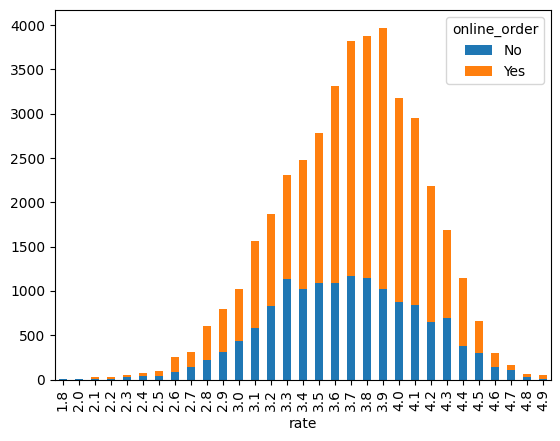

In [150]:
x.plot(kind='bar' , stacked=True) ## stacked=True gives basically stacked bar chart

In [25]:
### lets modify above bar-plot & get better results/inferences..

In [26]:
x

online_order,No,Yes
rate,,
1.8,5,0
2.0,11,0
2.1,9,15
2.2,10,16
2.3,29,22
2.4,36,34
2.5,38,63
2.6,83,177
2.7,141,166


In [151]:
## axis = 1 means summation across rows... , as by-default it is axis is 0
x.sum(axis = 1).astype(float)

rate
1.8       5.0
2.0      11.0
2.1      24.0
2.2      26.0
2.3      51.0
2.4      70.0
2.5     101.0
2.6     260.0
2.7     307.0
2.8     600.0
2.9     802.0
3.0    1023.0
3.1    1561.0
3.2    1873.0
3.3    2310.0
3.4    2476.0
3.5    2784.0
3.6    3316.0
3.7    3821.0
3.8    3873.0
3.9    3972.0
4.0    3183.0
4.1    2948.0
4.2    2184.0
4.3    1693.0
4.4    1147.0
4.5     656.0
4.6     300.0
4.7     167.0
4.8      66.0
4.9      55.0
dtype: float64

In [153]:
## we need Floating division of dataframe or normalized values of x dataframe across rows..just call x.div() & set axis = 0
## div is a in-built function of pandas designed for dataframe data-structure..

normalize_df = x.div(x.sum(axis=1).astype(float) , axis=0)

<Axes: xlabel='rate'>

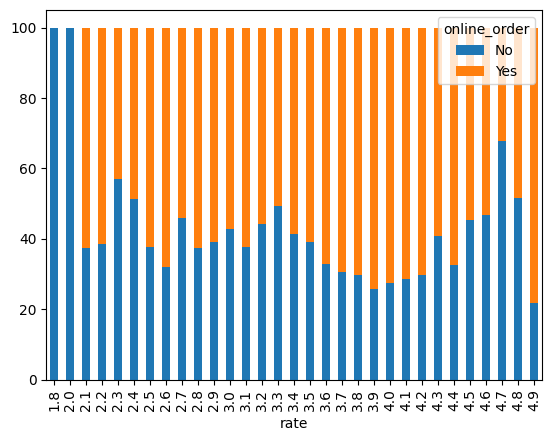

In [89]:
## lets multiply each value by 100 so that we will get much better results in % !

(normalize_df*100).plot(kind='bar' , stacked=True) ## stacked=True gives basically stacked bar chart

In [ ]:
'''
Inference :: 

⭐ High-rated restaurants (>4) mostly offer online ordering
🍔 Online ordering is common across most restaurants
⚖️ Lower-rated restaurants don’t always use online ordering
🚀 Online ordering helps reach more customers, but quality matters more

🚀 Conclusion: Online ordering is not the only factor for high ratings, but it supports better reach & customer engagement

💡 One-line takeaway:
    “Online ordering boosts reach — but quality drives ratings.”


'''

# 8.. What do People Prefer ? Cafe vs Italian vs Indian  !

In [ ]:
'''


Hi there , in the last session , We have deep dive into : Is Online Ordering a Game Changer ? !
& we have came up with a conclusion that : 

    “Online ordering boosts reach — but quality drives ratings.”



“Now in this session  , Lets talk about : 
What do People Prefer in Bengaluru ? Whether they are intestred in Cafe or in Italian or in Indian Cuisine !

At the end , u can think of having such Sunburst plot : 

📊 What this Sunburst Plot shows
    🌍 Center = Location (like Koramangala, BTM, etc.)
    🍽️ Outer layers = Cuisines available in that location
    📏 Size of each slice = Popularity / number of restaurants
    
    
🧠 Easy Understanding :

👉 It shows “Which locations offer which cuisines”
👉 And also “Which cuisines are most dominant in each area”




Lets make Inference from this Plot ! 
🍽️ North Indian & Cafe cuisines dominate across most locations
📍 Koramangala has the highest variety of cuisines (very diverse food hub)
🍕 Some areas specialize in specific cuisines (like Pizza, American, etc.)

💡 Takeaway:
    “Some areas offer everything, others specialize.”



& to create such plot , u need such structured data : [show img]


'''

In [154]:
data["cuisines"][0]

'North Indian, Mughlai, Chinese'

In [155]:
## Every restaurants have multiple cuisines, so we'll take the first cuisine to make Analysis Simple..

data['main_cuisine'] = data['cuisines'].str.split(',').str[0]

In [ ]:
data['main_cuisine']

In [156]:
data.isnull().sum()

index                              0
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                           10031
votes                              0
phone                           1187
location                           0
rest_type                        206
dish_liked                     28057
cuisines                          24
approx_cost(for two people)      325
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
main_cuisine                      24
dtype: int64

In [157]:
data.dropna(subset=["rest_type"],  inplace=True)

In [ ]:
'''

Just to make this Analysis simple , lets consider Popular or most voted locations of bnegaluru city !


'''

In [151]:
data["votes"].sum() ## total votes givenn by Users in bengaluru city !

14655685

In [152]:
data.groupby('location')['votes'].sum()

## So to find most voted locations of Bengaluru city , lets group all the rows of locations col & compute total votes for every loca

location
BTM , Bangalore , Karnataka , India                  614185
Banashankari , Bangalore , Karnataka , India         162374
Banaswadi , Bangalore , Karnataka , India             35217
Bannerghatta Road , Bangalore , Karnataka , India    217509
Basavanagudi , Bangalore , Karnataka , India          94919
                                                      ...  
West Bangalore , Bangalore , Karnataka , India         1110
Whitefield , Bangalore , Karnataka , India           465974
Wilson Garden , Bangalore , Karnataka , India          7341
Yelahanka , Bangalore , Karnataka , India               189
Yeshwantpur , Bangalore , Karnataka , India            6980
Name: votes, Length: 93, dtype: int64

In [155]:
data.groupby('location')['votes'].sum().nlargest(4).div(data['votes'].sum()).mul(100)

## lets divide every row by "total_votes" & then multiply by 100 to have values in % !

location
Koramangala 5th Block , Bangalore , Karnataka , India    15.144335
Indiranagar , Bangalore , Karnataka , India               8.152058
Koramangala 4th Block , Bangalore , Karnataka , India     4.675019
BTM , Bangalore , Karnataka , India                       4.190763
Name: votes, dtype: float64

In [ ]:
'''

top 4 locations covers around 32% of total votes of bengaluru !

'''

In [156]:
data.groupby('location')['votes'].sum().nlargest(4).index

Index(['Koramangala 5th Block , Bangalore , Karnataka , India',
       'Indiranagar , Bangalore , Karnataka , India',
       'Koramangala 4th Block , Bangalore , Karnataka , India',
       'BTM , Bangalore , Karnataka , India'],
      dtype='object', name='location')

In [159]:
top_locations = data.groupby('location')['votes'].sum().nlargest(4).index

In [160]:
top4_df = data[data['location'].isin(top_locations)]

In [161]:
top4_df.groupby(['location','rest_type'])['votes'].sum()

location                                               rest_type              
BTM , Bangalore , Karnataka , India                    Bakery                      1525
                                                       Bakery, Quick Bites          246
                                                       Bar                         2800
                                                       Bar, Casual Dining             0
                                                       Beverage Shop               3642
                                                                                  ...  
Koramangala 5th Block , Bangalore , Karnataka , India  Pub, Microbrewery           4910
                                                       Quick Bites                79761
                                                       Quick Bites, Food Court     1751
                                                       Sweet Shop                 11309
                                         

In [162]:
location_cuisine_votes = top4_df.groupby(['location','main_cuisine'])['votes'].sum().reset_index()

## Calculates total votes for each location–cuisine combination !

In [163]:
location_cuisine_votes.shape

(161, 3)

In [172]:
location_cuisine_votes

,location,main_cuisine,votes
0,"BTM , Bangalore , Karnataka , India",American,0
1,"BTM , Bangalore , Karnataka , India",Andhra,21594
2,"BTM , Bangalore , Karnataka , India",Arabian,30625
3,"BTM , Bangalore , Karnataka , India",Asian,5192
4,"BTM , Bangalore , Karnataka , India",Bakery,3013
...,...,...,...
156,"Koramangala 5th Block , Bangalore , Karnataka ...",Seafood,4078
157,"Koramangala 5th Block , Bangalore , Karnataka ...",South Indian,24082
158,"Koramangala 5th Block , Bangalore , Karnataka ...",Street Food,913
159,"Koramangala 5th Block , Bangalore , Karnataka ...",Tibetan,9741


In [165]:
location_cuisine_votes.columns

Index(['location', 'main_cuisine', 'votes'], dtype='object')

In [166]:
fig = px.sunburst(
    location_cuisine_votes ,
    path = ['location','main_cuisine'], # at center of sunburst , we will have location col , outler layers will be "main_cuisine"
    values = 'votes', ## 👍 Size of each part = number of votes (popularity)
    title = "Restaurant Types Across Major Locations"
)


In [ ]:
fig.show()

In [ ]:
'''

🍽️ North Indian & Cafe cuisines dominate across most locations
📍 Koramangala has the highest variety of cuisines (very diverse food hub)
🍕 Some areas specialize in specific cuisines (like Pizza, American, etc.)

'''

# 9.. If You Open a Restaurant Tomorrow… Where Should It Be?

    Restaurant Success Map !

In [ ]:
'''


Hi there , in the last session , We have deep dive into :  What do People Prefer ?
& we have came up with a conclusion that : 



“Now in this session  , Lets talk about : 
Imagine u want to Invest money & If You Open a Restaurant Tomorrow… then Where Should It Be?


Now the question u may have is : 
📊 How to Decide Where to Open a Restaurant

You want locations with:

✔ High demand (many votes)
✔ Good ratings
✔ Moderate competition


At the end , u can think of having such plot which tells u that : 

🟢 Large Green Circles → High Demand Areas

    Circle size = number of votes

    More votes = higher customer demand

    Example from the map:
    HSR Layout / Bellandur region shows very large circles → extremely popular restaurant areas.




Lets make Inference from this Plot ! 

🟢 Large Green Circles → High Demand Areas

Circle size = number of votes

More votes = higher customer demand

Example from the map:

HSR Layout / Bellandur region shows very large circles → extremely popular restaurant areas.










📊 How to Decide Where to Open a Restaurant

You want locations with:

✔ High demand (many votes)
✔ Good ratings
✔ Moderate competition




📍 Key Insights from This Map
1️⃣ Koramangala / HSR / Bellandur

Very large bubbles
High votes
Strong ratings
BUT extremely high competition

➡ Great market but Highly Saturated Areas (Avoid if Possible)









🚀 Best Areas to Open a Restaurant (Highlighted Strategy)
1️⃣ HSR Layout – Top Opportunity Zone

⭕ Recommended Circle Area

Why:

Very large demand bubbles
Mostly dark green (high ratings)
Strong tech crowd (IT corridor)

Growing residential population


2️⃣ Bellandur / Sarjapur Road

⭕ Recommended Circle Area

Why:

Several large demand bubbles
Tech offices nearby
High food delivery usage
Still expanding restaurant ecosystem



3️⃣ Whitefield Corridor

⭕ Recommended Circle Area

Why:

Large bubbles on east side of map
Tech parks + expat population
Many premium restaurants succeed here

Best suited for:

premium dining
cafe concepts
cloud kitchens




🗺 Final Recommendation

If opening one restaurant tomorrow:

🥇 HSR Layout
🥈 Bellandur / Sarjapur Road
🥉 Whitefield

These zones offer the best balance of demand, rating potential, and competition.


'''

In [ ]:
'''


Keep bubble size = demand (votes)

Keep color = rating

Show location + restaurant name

Slightly normalize bubble size so huge votes don't dominate


'''

In [313]:
data = df.copy()

In [168]:
data["rate"]

0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51712    3.6
51713    NaN
51714    NaN
51715    4.3
51716    3.4
Name: rate, Length: 51466, dtype: float64

In [279]:
# filter successful restaurants
success_df = data[(data['rate'] >= 4.0) & (data['votes'] >= 100)]

In [280]:
success_df.shape

(10908, 19)

In [281]:
success_df.columns

Index(['index', 'url', 'address', 'name', 'online_order', 'book_table', 'rate',
       'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)', 'main_cuisine'],
      dtype='object')

In [282]:
Ratings_locations.columns

Index(['Name', 'avg_rating', 'Total_Restaurant', 'lat', 'lon'], dtype='object')

In [283]:
success_df = success_df.merge(Ratings_locations , left_on="location" , right_on = "Name" ,  how = "left")

In [284]:
success_df.isnull().sum()

index                            0
url                              0
address                          0
name                             0
online_order                     0
book_table                       0
rate                             0
votes                            0
phone                          235
location                         0
rest_type                        0
dish_liked                      56
cuisines                         0
approx_cost(for two people)     71
reviews_list                     0
menu_item                        0
listed_in(type)                  0
listed_in(city)                  0
main_cuisine                     0
Name                             0
avg_rating                       0
Total_Restaurant                 0
lat                              0
lon                              0
dtype: int64

In [273]:
'''


On the map:

🟢 Green dots = Highly successful restaurants

Clusters indicate:

popular food areas

high demand zones


'''

'\n\n\nOn the map:\n\n🟢 Green dots = Highly successful restaurants\n\nClusters indicate:\n\npopular food areas\n\nhigh demand zones\n\n\n'

In [274]:
'''

⭐ Small Improvement (Very Nice Visual)

Show restaurant name + rating + votes.

Replace popup line with:


'''

'\n\n⭐ Small Improvement (Very Nice Visual)\n\nShow restaurant name + rating + votes.\n\nReplace popup line with:\n\n\n'

In [276]:
'''

⭐ What This Improves
Hover (tooltip)

    When you hover:
    Indiranagar | Rating: 4.5
    
    
    Click popup

    When you click:

    Indiranagar
    ⭐ Rating: 4.5
    👍 Votes: 3200


'''

'\n\n⭐ What This Improves\nHover (tooltip)\n\n    When you hover:\n    Indiranagar | Rating: 4.5\n    \n    \n    Click popup\n\n    When you click:\n\n    Indiranagar\n    ⭐ Rating: 4.5\n    👍 Votes: 3200\n\n\n'

In [294]:
## lets first create basemap of Bengaluru city !
map_success = folium.Map(location = [12.9716,77.5946] , zoom_start = 12)

## iterate on top of "success_df"
for index , row in success_df.iterrows():

    popup_html = f"""
    <b>{row['name']}</b><br>
    ⭐ Rating: {row['rate']}<br>
    👍 Votes: {row['votes']}
    """

    if row['rate'] >= 4.7:
        color = "#006400"   # dark green
    elif row['rate'] >= 4.3:
        color = "#2ECC71"   # green
    else:
        color = "#FD8D3C"   # Orange 


    ## we have to create a bubble for every locaton , so call folium.CircleMarker() inside loop !  
    folium.CircleMarker(
        location=[row['lat'], row['lon']],

        # bubble size = demand
        radius = row['votes']/400,

        color = "white", ## Add white borders instead of black for cleaner visualization
        fill_color = color,   # use the computed color,
        fill_opacity = 0.8,
        weight = 1,

        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"{row['name']} | Rating: {row['rate']}" ## show name & rating when u hover on map !
        
    ).add_to(map_success)

In [ ]:
map_success ## takes around 15-20 secs 

## takes around 15-20 extra MB for notebook !

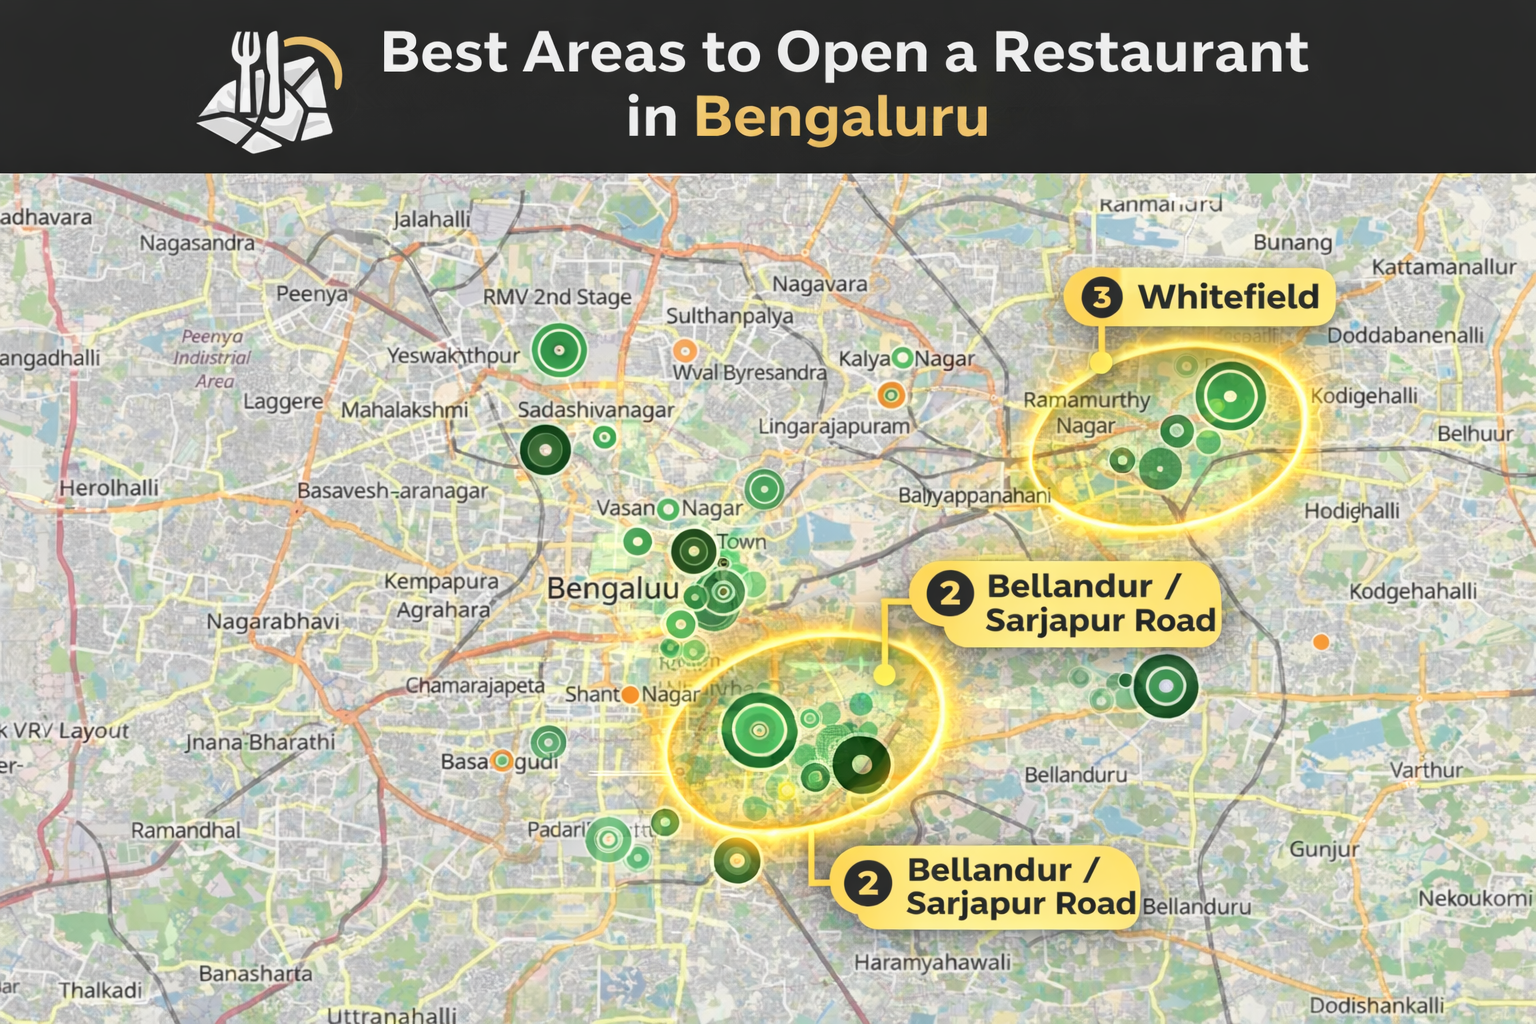

In [ ]:
## lets add Marker cluster to existing Map !
## [ show plot ]

In [256]:
from folium.plugins import MarkerCluster

cluster = MarkerCluster().add_to(map_success)

In [257]:
from folium.plugins import MarkerCluster


# create marker cluster layer
marker_cluster = MarkerCluster().add_to(map_success)

for index,row in success_df.iterrows():

    popup_html = f"""
    <b>{row['name']}</b><br>
    ⭐ Rating: {row['rate']}<br>
    👍 Votes: {row['votes']}
    """

    # color based on rating
    if row['rate'] >= 4.6:
        color = "#006400"   # dark green
    elif row['rate'] >= 4.3:
        color = "#66C266"   # light green
    else:
        color = "#FD8D3C"   # orange

    folium.CircleMarker(
        location=[row['lat'], row['lon']],

        # bubble size = demand
        radius=row['votes']/400,

        color="white",
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        weight=1,

        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"{row['name']} | Rating: {row['rate']}"
        
    ).add_to(marker_cluster)   # add to cluster instead of map



In [ ]:
display(map_success) ## takes 30-40 secs to render it !

## this plot will take alot time !

In [ ]:
'''

🟢 Large Green Circles → High Demand Areas

Circle size = number of votes

More votes = higher customer demand

Example from the map:

HSR Layout / Bellandur region shows very large circles → extremely popular restaurant areas.



📊 How to Decide Where to Open a Restaurant

You want locations with:

✔ High demand (many votes)
✔ Good ratings
✔ Moderate competition








📍 Key Insights from This Map
1️⃣ Koramangala / HSR / Bellandur

Very large bubbles
High votes
Strong ratings
BUT extremely high competition

➡ Great market but saturated.

2️⃣ Indiranagar / Central Bengaluru

Strong demand
Many successful restaurants
Premium dining area

➡ Suitable for high-end restaurants.

3️⃣ Outer Bangalore Zones

Fewer clusters
Smaller bubbles
Lower competition

➡ Good opportunity zones for new restaurants...







'''